# 🏠 Ames Housing Price Prediction
## EDA · Preprocessing · Modelling · Evaluation

**Assignment pipeline covered in this notebook:**
1. Load & inspect the dataset
2. Standardise column names
3. Dataset understanding (shape, dtypes, duplicates, missing values)
4. Structural missing-value handling
5. Manual EDA (distributions, correlations, outliers)
6. Automated EDA with *ydata-profiling*
7. Feature-group separation (numerical / nominal / ordinal)
8. Train / Validation / Test split
9. sklearn `Pipeline` + `ColumnTransformer` (leakage-safe)
10. Model training — **SVR** and **Ridge Regression**
11. `GridSearchCV` hyperparameter tuning
12. Evaluation — MAE, MSE, RMSE, R²


## 1 · Import Libraries

In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


## 2 · Settings

In [3]:
RANDOM_STATE = 42
TARGET       = "SalePrice"
DATA_PATH    = Path("AmesHousing.csv")
OUTPUT_DIR   = Path("ames_eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 3 · Load Data

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "AmesHousing.csv not found. Place it in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 4 · Standardise Column Names

Convert all column names to `Snake_Case` and resolve common aliases so the
rest of the notebook uses consistent identifiers regardless of the CSV variant.


In [5]:
def normalize_column_name(col: str) -> str:
    """'Overall Qual' → 'Overall_Qual'  |  'Gr Liv Area' → 'Gr_Liv_Area'"""
    col = str(col).strip()
    col = re.sub(r"[^0-9A-Za-z]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")


df.columns = [normalize_column_name(c) for c in df.columns]

# Resolve common name variations between dataset releases
column_aliases = {
    "Sale_Price": "SalePrice", "MSSubClass": "MS_SubClass",
    "MSZoning": "MS_Zoning", "LotFrontage": "Lot_Frontage",
    "LotArea": "Lot_Area", "LotShape": "Lot_Shape",
    "LandContour": "Land_Contour", "LotConfig": "Lot_Config",
    "LandSlope": "Land_Slope", "OverallQual": "Overall_Qual",
    "OverallCond": "Overall_Cond", "YearBuilt": "Year_Built",
    "YearRemodAdd": "Year_Remod_Add", "RoofStyle": "Roof_Style",
    "RoofMatl": "Roof_Matl", "Exterior1st": "Exterior_1st",
    "Exterior2nd": "Exterior_2nd", "MasVnrType": "Mas_Vnr_Type",
    "MasVnrArea": "Mas_Vnr_Area", "ExterQual": "Exter_Qual",
    "ExterCond": "Exter_Cond", "BsmtQual": "Bsmt_Qual",
    "BsmtCond": "Bsmt_Cond", "BsmtExposure": "Bsmt_Exposure",
    "BsmtFinType1": "BsmtFin_Type_1", "BsmtFinSF1": "BsmtFin_SF_1",
    "BsmtFinType2": "BsmtFin_Type_2", "BsmtFinSF2": "BsmtFin_SF_2",
    "BsmtUnfSF": "BsmtUnf_SF", "TotalBsmtSF": "Total_Bsmt_SF",
    "HeatingQC": "Heating_QC", "CentralAir": "Central_Air",
    "1stFlrSF": "1st_Flr_SF", "2ndFlrSF": "2nd_Flr_SF",
    "LowQualFinSF": "Low_Qual_Fin_SF", "GrLivArea": "Gr_Liv_Area",
    "BsmtFullBath": "Bsmt_Full_Bath", "BsmtHalfBath": "Bsmt_Half_Bath",
    "FullBath": "Full_Bath", "HalfBath": "Half_Bath",
    "Bedroom": "Bedroom_Abv_Gr", "Kitchen": "Kitchen_Abv_Gr",
    "KitchenQual": "Kitchen_Qual", "TotRmsAbvGrd": "TotRms_Abv_Grd",
    "FireplaceQu": "Fireplace_Qu", "GarageType": "Garage_Type",
    "GarageYrBlt": "Garage_Yr_Blt", "GarageFinish": "Garage_Finish",
    "GarageCars": "Garage_Cars", "GarageArea": "Garage_Area",
    "GarageQual": "Garage_Qual", "GarageCond": "Garage_Cond",
    "PavedDrive": "Paved_Drive", "WoodDeckSF": "Wood_Deck_SF",
    "OpenPorchSF": "Open_Porch_SF", "EnclosedPorch": "Enclosed_Porch",
    "3SsnPorch": "3Ssn_Porch", "ScreenPorch": "Screen_Porch",
    "PoolArea": "Pool_Area", "PoolQC": "Pool_QC",
    "MiscFeature": "Misc_Feature", "MiscVal": "Misc_Val",
    "MoSold": "Mo_Sold", "YrSold": "Yr_Sold",
    "SaleType": "Sale_Type", "SaleCondition": "Sale_Condition",
}
for old, new in column_aliases.items():
    if old in df.columns and new not in df.columns:
        df.rename(columns={old: new}, inplace=True)

if TARGET not in df.columns:
    raise ValueError(f"'{TARGET}' not found.  Columns: {df.columns.tolist()}")

print("Column names normalised ✓")
print(f"Final shape: {df.shape}")


Column names normalised ✓
Final shape: (2930, 82)


## 5 · Dataset Understanding

In [6]:
print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nData-type counts:")
print(df.dtypes.value_counts())


Shape: (2930, 82)
Duplicate rows: 0

Data-type counts:
object     43
int64      28
float64    11
Name: count, dtype: int64


In [7]:
df.dtypes

Order                int64
PID                  int64
MS_SubClass          int64
MS_Zoning           object
Lot_Frontage       float64
Lot_Area             int64
Street              object
Alley               object
Lot_Shape           object
Land_Contour        object
Utilities           object
Lot_Config          object
Land_Slope          object
Neighborhood        object
Condition_1         object
Condition_2         object
Bldg_Type           object
House_Style         object
Overall_Qual         int64
Overall_Cond         int64
Year_Built           int64
Year_Remod_Add       int64
Roof_Style          object
Roof_Matl           object
Exterior_1st        object
Exterior_2nd        object
Mas_Vnr_Type        object
Mas_Vnr_Area       float64
Exter_Qual          object
Exter_Cond          object
Foundation          object
Bsmt_Qual           object
Bsmt_Cond           object
Bsmt_Exposure       object
BsmtFin_Type_1      object
BsmtFin_SF_1       float64
BsmtFin_Type_2      object
B

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,2930.0,NaN,NaN,NaN,1465.5,845.96247,1.0,733.25,1465.5,2197.75,2930.0
PID,2930.0,NaN,NaN,NaN,714464496.988737,188730844.64939,526301100.0,528477022.5,535453620.0,907181097.5,1007100110.0
MS_SubClass,2930.0,NaN,NaN,NaN,57.387372,42.638025,20.0,20.0,50.0,70.0,190.0
MS_Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot_Frontage,2440.0,NaN,NaN,NaN,69.22459,23.365335,21.0,58.0,68.0,80.0,313.0
Lot_Area,2930.0,NaN,NaN,NaN,10147.921843,7880.017759,1300.0,7440.25,9436.5,11555.25,215245.0
Street,2930,2,Pave,2918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,198,2,Grvl,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot_Shape,2930,4,Reg,1859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land_Contour,2930,4,Lvl,2633,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6 · Duplicate Handling

In [9]:
n_dup = df.duplicated().sum()
if n_dup:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {n_dup} duplicate rows.")
else:
    print("No duplicate rows found ✓")


No duplicate rows found ✓


## 7 · Structural Missing Values

In the Ames dataset a `NaN` in several categorical columns does **not** mean
"unknown" — it means the feature is absent (no basement, no garage, etc.).
These are filled with `"None"` before imputation so the absence becomes a
valid, informative category.


In [10]:
absence_features = [
    "Alley", "Mas_Vnr_Type", "Bsmt_Qual", "Bsmt_Cond", "Bsmt_Exposure",
    "BsmtFin_Type_1", "BsmtFin_Type_2", "Fireplace_Qu", "Garage_Type",
    "Garage_Finish", "Garage_Qual", "Garage_Cond", "Pool_QC", "Fence",
    "Misc_Feature",
]
for col in absence_features:
    if col in df.columns:
        df[col] = df[col].astype("object").fillna("None")

print("Structural NaN values filled with 'None' ✓")


Structural NaN values filled with 'None' ✓


## 8 · Missing-Value Report

In [11]:
missing_summary = pd.DataFrame({
    "Missing_Count":      df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2),
}).sort_values("Missing_Count", ascending=False)

only_missing = missing_summary[missing_summary["Missing_Count"] > 0]
print(f"{len(only_missing)} columns still have missing values after structural fill.")
only_missing.to_csv(OUTPUT_DIR / "missing_values_summary.csv")
only_missing


12 columns still have missing values after structural fill.


,Missing_Count,Missing_Percentage
Lot_Frontage,490,16.72
Garage_Yr_Blt,159,5.43
Mas_Vnr_Area,23,0.78
Bsmt_Full_Bath,2,0.07
Bsmt_Half_Bath,2,0.07
BsmtFin_SF_2,1,0.03
Bsmt_Unf_SF,1,0.03
Electrical,1,0.03
BsmtFin_SF_1,1,0.03
Garage_Cars,1,0.03


## 9 · Target Variable — `SalePrice`

In [12]:
print(df[TARGET].describe())
if df[TARGET].isnull().sum():
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    print("Rows with missing SalePrice dropped.")


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 10 · Manual EDA

In [13]:
numeric_columns     = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Numerical features  : {len(numeric_columns)}")
print(f"Categorical features: {len(categorical_columns)}")


Numerical features  : 39
Categorical features: 43


### 10.1 SalePrice Distribution

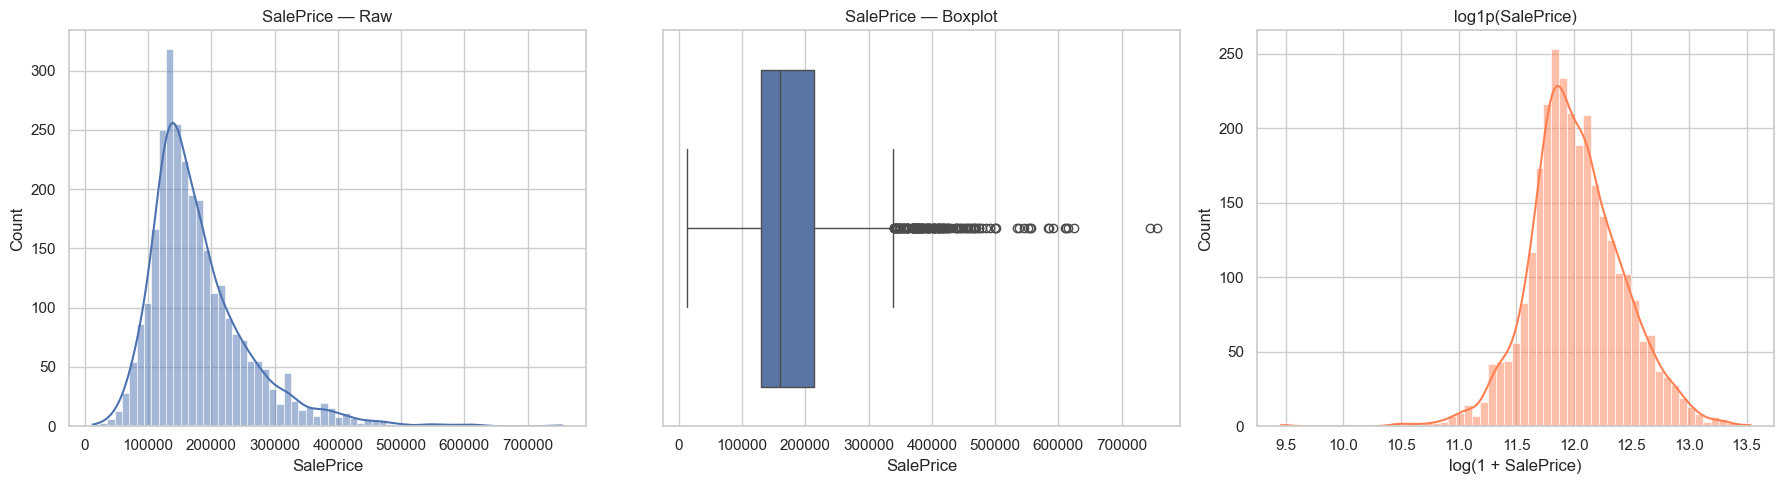

SalePrice skewness         : 1.744
log1p(SalePrice) skewness  : -0.015


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df[TARGET], kde=True, ax=axes[0])
axes[0].set_title("SalePrice — Raw")
axes[0].set_xlabel("SalePrice")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("SalePrice — Boxplot")

log_sp = np.log1p(df[TARGET])
sns.histplot(log_sp, kde=True, ax=axes[2], color="coral")
axes[2].set_title("log1p(SalePrice)")
axes[2].set_xlabel("log(1 + SalePrice)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "saleprice_panels.png", dpi=150)
plt.show()

print(f"SalePrice skewness         : {df[TARGET].skew():.3f}")
print(f"log1p(SalePrice) skewness  : {log_sp.skew():.3f}")


### 10.2 Skewed Numerical Features

In [15]:
eda_numeric = df.drop(columns=[TARGET], errors="ignore").select_dtypes(include=np.number)
skewness = eda_numeric.skew().sort_values(key=abs, ascending=False)
skewness.to_csv(OUTPUT_DIR / "feature_skewness.csv")
skewness.head(20)


Misc_Val           21.999788
Pool_Area          16.939142
Lot_Area           12.820898
Low_Qual_Fin_SF    12.118162
3Ssn_Porch         11.403795
Kitchen_AbvGr       4.313825
BsmtFin_SF_2        4.139978
Enclosed_Porch      4.014446
Screen_Porch        3.957467
Bsmt_Half_Bath      3.940795
Mas_Vnr_Area        2.606985
Open_Porch_SF       2.535386
Wood_Deck_SF        1.842678
Lot_Frontage        1.499067
1st_Flr_SF          1.469429
BsmtFin_SF_1        1.416182
MS_SubClass         1.357579
Gr_Liv_Area         1.274110
Total_Bsmt_SF       1.156204
Bsmt_Unf_SF         0.923053
dtype: float64

### 10.3 Key Features vs SalePrice

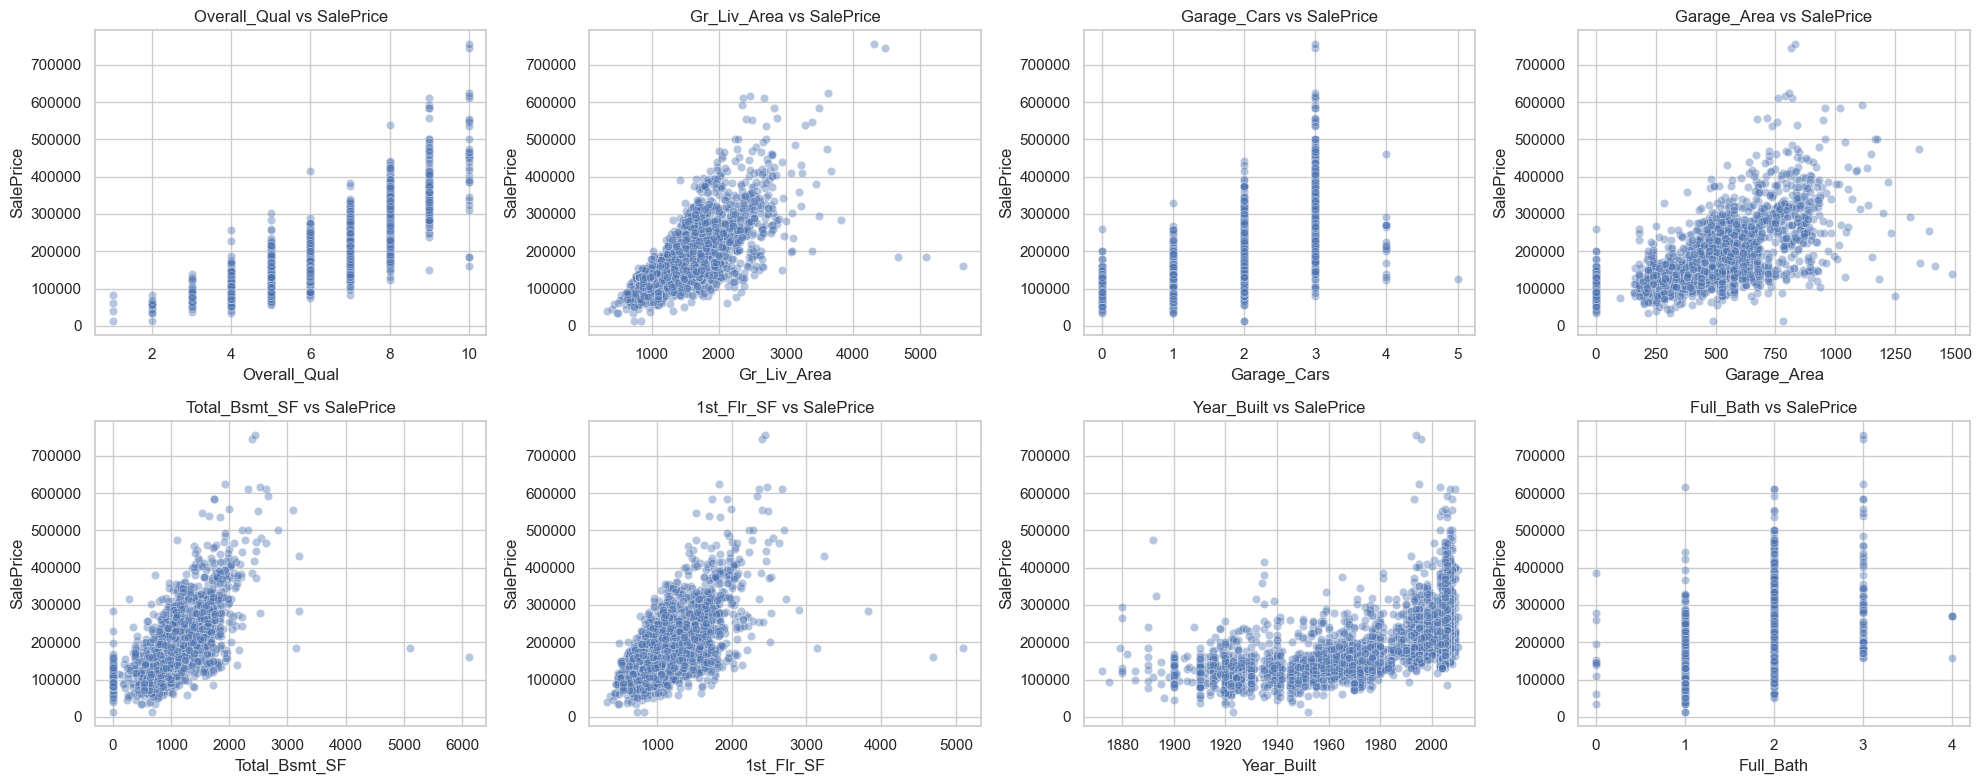

In [16]:
important_features = [
    "Overall_Qual", "Gr_Liv_Area", "Garage_Cars", "Garage_Area",
    "Total_Bsmt_SF", "1st_Flr_SF", "Year_Built", "Full_Bath",
]
important_features = [f for f in important_features if f in df.columns]

n = len(important_features)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, feat in enumerate(important_features):
    sns.scatterplot(data=df, x=feat, y=TARGET, alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{feat} vs SalePrice")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "features_vs_saleprice.png", dpi=150)
plt.show()


### 10.4 Correlation Analysis

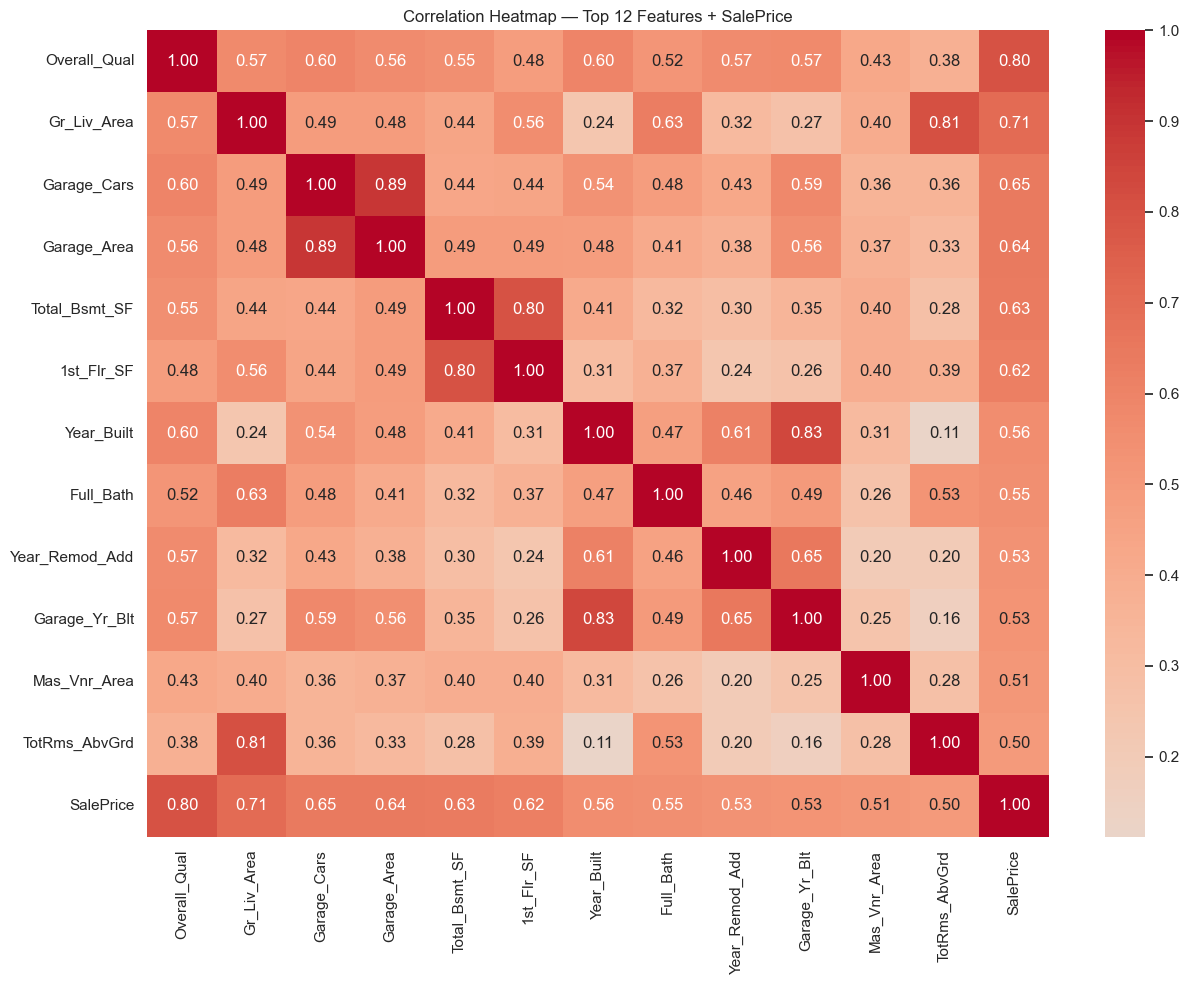

Overall_Qual      0.799262
Gr_Liv_Area       0.706780
Garage_Cars       0.647877
Garage_Area       0.640401
Total_Bsmt_SF     0.632280
1st_Flr_SF        0.621676
Year_Built        0.558426
Full_Bath         0.545604
Year_Remod_Add    0.532974
Garage_Yr_Blt     0.526965
Mas_Vnr_Area      0.508285
TotRms_AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin_SF_1      0.432914
Lot_Frontage      0.357318
Name: SalePrice, dtype: float64

In [17]:
correlations = (
    df.select_dtypes(include=np.number)
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
correlations.to_csv(OUTPUT_DIR / "saleprice_correlations.csv")

top_feats = correlations.head(12).index.tolist() + [TARGET]
plt.figure(figsize=(13, 10))
sns.heatmap(
    df[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title("Correlation Heatmap — Top 12 Features + SalePrice")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

correlations.head(15)


### 10.5 Neighbourhood & Overall Quality

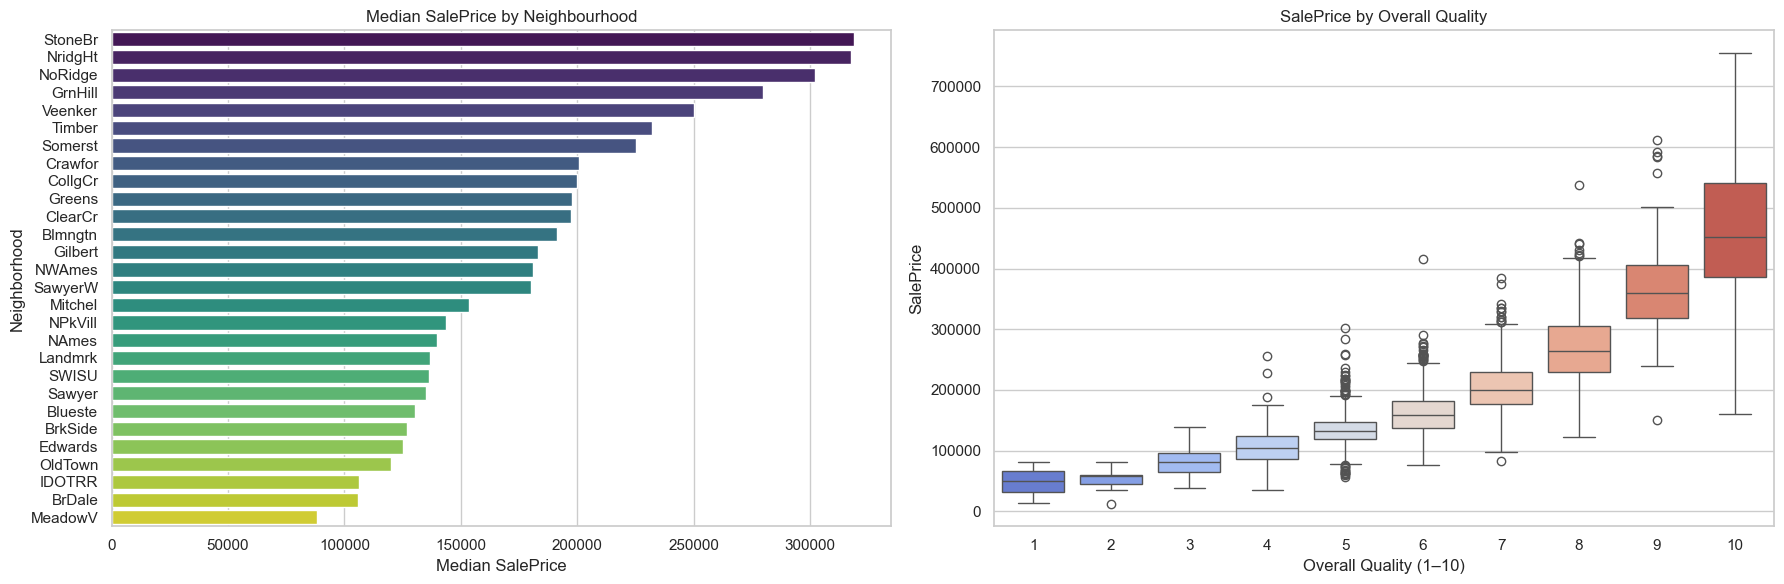

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if "Neighborhood" in df.columns:
    nb_price = df.groupby("Neighborhood")[TARGET].median().sort_values(ascending=False)
    sns.barplot(x=nb_price.values, y=nb_price.index, ax=axes[0], palette="viridis")
    axes[0].set_title("Median SalePrice by Neighbourhood")
    axes[0].set_xlabel("Median SalePrice")

if "Overall_Qual" in df.columns:
    sns.boxplot(data=df, x="Overall_Qual", y=TARGET, ax=axes[1], palette="coolwarm")
    axes[1].set_title("SalePrice by Overall Quality")
    axes[1].set_xlabel("Overall Quality (1–10)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "neighbourhood_and_quality.png", dpi=150)
plt.show()


### 10.6 IQR Outlier Counts

In [19]:
def count_iqr_outliers(s: pd.Series) -> int:
    v = s.dropna()
    if v.empty:
        return 0
    q1, q3 = v.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).sum())


outlier_table = (
    pd.DataFrame(
        {col: count_iqr_outliers(df[col]) for col in numeric_columns if col != TARGET},
        index=["Outlier_Count"],
    )
    .T.sort_values("Outlier_Count", ascending=False)
)
outlier_table.to_csv(OUTPUT_DIR / "iqr_outlier_counts.csv")
outlier_table.head(20)


,Outlier_Count
Enclosed_Porch,459
BsmtFin_SF_2,351
Screen_Porch,256
Overall_Cond,252
MS_SubClass,208
Mas_Vnr_Area,200
Lot_Frontage,187
Bsmt_Half_Bath,175
Open_Porch_SF,159
Kitchen_AbvGr,134


## 11 · Automated EDA — `ydata-profiling`

> **Install:** `pip install ydata-profiling`
> 
> The HTML report is saved to `ames_eda_outputs/ames_ydata_profile.html`.


In [20]:
try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(df, title="Ames Housing Automated EDA", explorative=True)
    profile_path = OUTPUT_DIR / "ames_ydata_profile.html"
    profile.to_file(profile_path)
    print(f"Profile report saved → {profile_path.resolve()}")
except ImportError:
    print("ydata-profiling not installed.  Run:  pip install ydata-profiling")


Export report to file: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]

Profile report saved → L:\nti_pr\ames_eda_outputs\ames_ydata_profile.html


## 12 · Feature Groups

### 12.1 Ordinal Features & Category Orders

In [21]:
ordinal_categories = {
    "Lot_Shape":       ["IR3", "IR2", "IR1", "Reg"],
    "Land_Slope":      ["Sev", "Mod", "Gtl"],
    "Exter_Qual":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter_Cond":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt_Qual":       ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt_Cond":       ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt_Exposure":   ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFin_Type_1":  ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin_Type_2":  ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Heating_QC":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen_Qual":    ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional":      ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Fireplace_Qu":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage_Finish":   ["None", "Unf", "RFn", "Fin"],
    "Garage_Qual":     ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage_Cond":     ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Paved_Drive":     ["N", "P", "Y"],
    "Pool_QC":         ["None", "Fa", "TA", "Gd", "Ex"],
    "Fence":           ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"],
}

ordinal_features = [c for c in ordinal_categories if c in df.columns]
print(f"Ordinal features present in dataset: {len(ordinal_features)}")
ordinal_features


Ordinal features present in dataset: 19


['Lot_Shape',
 'Land_Slope',
 'Exter_Qual',
 'Exter_Cond',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_Type_2',
 'Heating_QC',
 'Kitchen_Qual',
 'Functional',
 'Fireplace_Qu',
 'Garage_Finish',
 'Garage_Qual',
 'Garage_Cond',
 'Paved_Drive',
 'Pool_QC',
 'Fence']

### 12.2 Nominal Features

In [22]:
nominal_candidates = [
    "MS_SubClass", "MS_Zoning", "Street", "Alley", "Utilities", "Lot_Config",
    "Neighborhood", "Condition_1", "Condition_2", "Bldg_Type", "House_Style",
    "Roof_Style", "Roof_Matl", "Exterior_1st", "Exterior_2nd", "Mas_Vnr_Type",
    "Foundation", "Heating", "Central_Air", "Electrical", "Garage_Type",
    "Misc_Feature", "Sale_Type", "Sale_Condition",
]
nominal_features = [c for c in nominal_candidates if c in df.columns]
print(f"Nominal features: {len(nominal_features)}")
nominal_features


Nominal features: 24


['MS_SubClass',
 'MS_Zoning',
 'Street',
 'Alley',
 'Utilities',
 'Lot_Config',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Foundation',
 'Heating',
 'Central_Air',
 'Electrical',
 'Garage_Type',
 'Misc_Feature',
 'Sale_Type',
 'Sale_Condition']

### 12.3 Numerical Features

In [23]:
excluded = {TARGET} | set(nominal_features) | set(ordinal_features)
numeric_features = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in excluded
]

print(f"Numerical : {len(numeric_features)}")
print(f"Nominal   : {len(nominal_features)}")
print(f"Ordinal   : {len(ordinal_features)}")


Numerical : 37
Nominal   : 24
Ordinal   : 19


## 13 · Train / Validation / Test Split

| Set        | Proportion |
|------------|-----------|
| Train      | 70 %      |
| Validation | 15 %      |
| Test       | 15 %      |


In [24]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_temp,  y_train, y_temp  = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val,   X_test,  y_val,   y_test  = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")

pd.DataFrame({
    "Train":      y_train.describe(),
    "Validation": y_val.describe(),
    "Test":       y_test.describe(),
})


Train      : (2051, 81)
Validation : (439, 81)
Test       : (440, 81)


,Train,Validation,Test
count,2051.000000,439.000000,440.000000
mean,178641.250122,184719.403189,186925.986364
std,78030.406571,82845.663463,84998.006772
min,12789.000000,52000.000000,35311.000000
25%,129000.000000,129000.000000,131000.000000
50%,160000.000000,163000.000000,165750.000000
75%,210000.000000,224750.000000,225375.000000
max,755000.000000,610000.000000,625000.000000


## 14 · Identify Skewed Features for Log Transform

> **Leakage safety**: skewness thresholds are computed on the **training set only**.
> Year/month columns are excluded — their integer values are not area/count distributions.


In [25]:
positive_candidates = [
    c for c in numeric_features
    if c in X_train.columns
    and not re.search(r"(Year|Yr_|Mo_)", c, re.IGNORECASE)
    and X_train[c].dropna().min() >= 0
]

train_skew = X_train[positive_candidates].skew().abs().dropna()

log_numeric_features     = train_skew[train_skew > 0.75].index.tolist()
regular_numeric_features = [c for c in numeric_features if c not in log_numeric_features]

print(f"Features → log1p transform  : {len(log_numeric_features)}")
print(f"Features → regular scaling  : {len(regular_numeric_features)}")
log_numeric_features


Features → log1p transform  : 23
Features → regular scaling  : 14


['Lot_Frontage',
 'Lot_Area',
 'Mas_Vnr_Area',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Half_Bath',
 'Half_Bath',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Enclosed_Porch',
 '3Ssn_Porch',
 'Screen_Porch',
 'Pool_Area',
 'Misc_Val']

## 15 · Preprocessing Pipelines

Four sub-pipelines are combined inside a single `ColumnTransformer`:

| Sub-pipeline | Features | Steps |
|---|---|---|
| `numeric` | Regular numerical | Median impute → StandardScaler |
| `log_numeric` | Skewed numerical | Median impute → log1p → StandardScaler |
| `nominal` | Nominal categorical | Most-frequent impute → OneHotEncoder |
| `ordinal` | Ordinal categorical | Most-frequent impute → OrdinalEncoder (ordered) |

> **Why median imputation?** Median is robust to outliers, which are common in housing data.  
> **Why StandardScaler?** SVR is sensitive to feature scale and requires normalised inputs.  
> **Why log1p before scaling skewed features?** It compresses large tails and makes distributions more Gaussian, which benefits both linear and kernel methods.


In [26]:
# ── Numerical pipeline ──────────────────────────────────────────────────
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler",  StandardScaler()),
])

# ── Log-numerical pipeline ───────────────────────────────────────────────
log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p",   FunctionTransformer(np.log1p)),
    ("scaler",  StandardScaler()),
])

# ── Nominal pipeline ─────────────────────────────────────────────────────
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  ohe),
])

# ── Ordinal pipeline ─────────────────────────────────────────────────────
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[ordinal_categories[c] for c in ordinal_features],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )),
])

# ── ColumnTransformer ────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric",     numeric_pipeline,     regular_numeric_features),
        ("log_numeric", log_numeric_pipeline,  log_numeric_features),
        ("nominal",     nominal_pipeline,      nominal_features),
        ("ordinal",     ordinal_pipeline,      ordinal_features),
    ],
    remainder="drop",
)

print("ColumnTransformer built ✓")


ColumnTransformer built ✓
